In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS

In [3]:


# Read the FITS file
fits_path = 'MeerKAT_beam_zenith.fits'
hdu = fits.open(fits_path)

# Print info about the file structure
hdu.info()

# Get the image data and header
data = hdu[0].data
header = hdu[0].header

# Print header to understand the image
print("\nHeader keywords:")
print(repr(header))

Filename: MeerKAT_beam_zenith.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      20   (20, 20)   float64   

Header keywords:
SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   20                                                  
NAXIS2  =                   20                                                  
WCSAXES =                    2 / Number of coordinate axes                      
CRPIX1  =                 11.0 / Pixel coordinate of reference point            
CRPIX2  =                 11.0 / Pixel coordinate of reference point            
CDELT1  =  -0.0019444444444444 / [deg] Coordinate increment at reference point  
CDELT2  =   0.0019444444444444 / [deg] Coordinate increment at reference point  
CUNIT1  = '

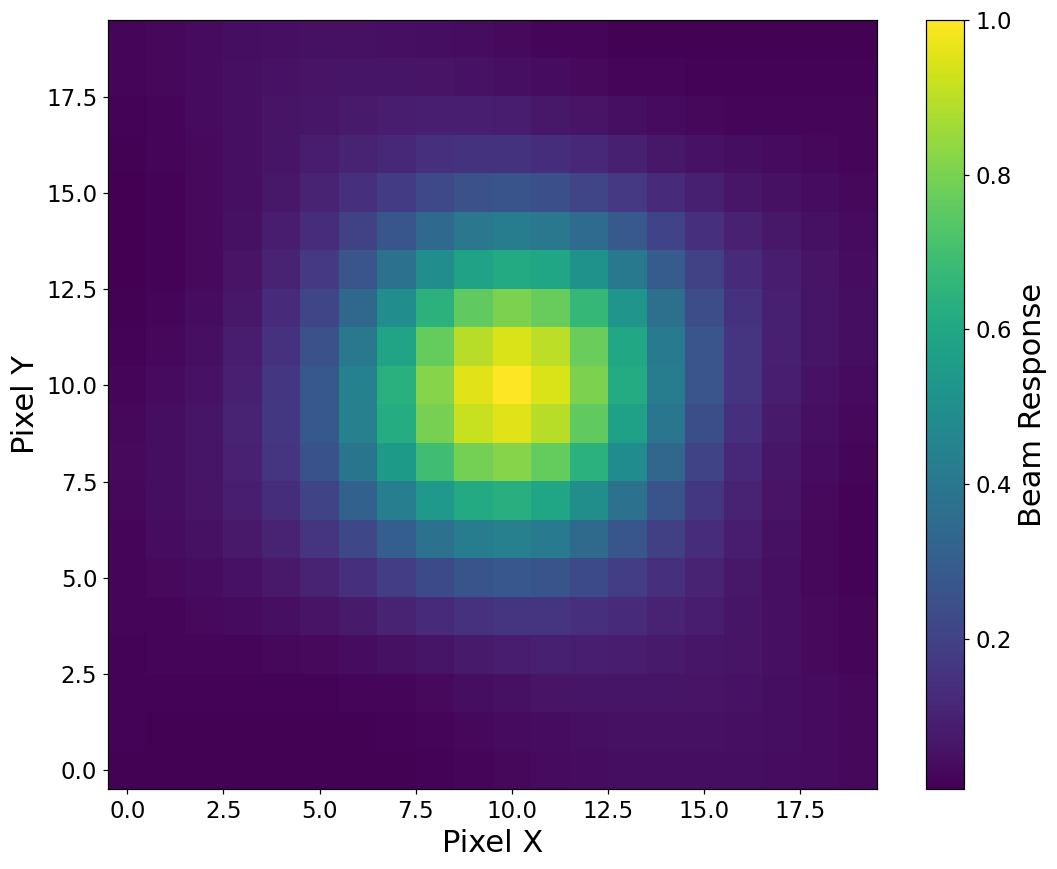

In [9]:
# Basic plot of the beam
fig, ax = plt.subplots(figsize=(10, 8), dpi=110)

# Handle different data dimensions (some FITS have extra axes)
if data.ndim == 4:
    # Take first frequency and polarization channel
    plot_data = data[0, 0, :, :]
elif data.ndim == 3:
    plot_data = data[0, :, :]
else:
    plot_data = data

# Plot the beam pattern
im = ax.imshow(plot_data, origin='lower', cmap='viridis')
cbar = plt.colorbar(im, ax=ax, label='Beam Response')
cbar.ax.tick_params(labelsize=15)
cbar.set_label('Beam Response', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel('Pixel X', fontsize=20)
ax.set_ylabel('Pixel Y', fontsize=20)
# ax.set_title('MeerKAT Tied-Array Beam Pattern')
plt.tight_layout()
plt.show()

Pixel scale: 7.0000 arcsec/px (x), 7.0000 arcsec/px (y)
Peak location: pixel (10, 10)
Peak value: 1.0000


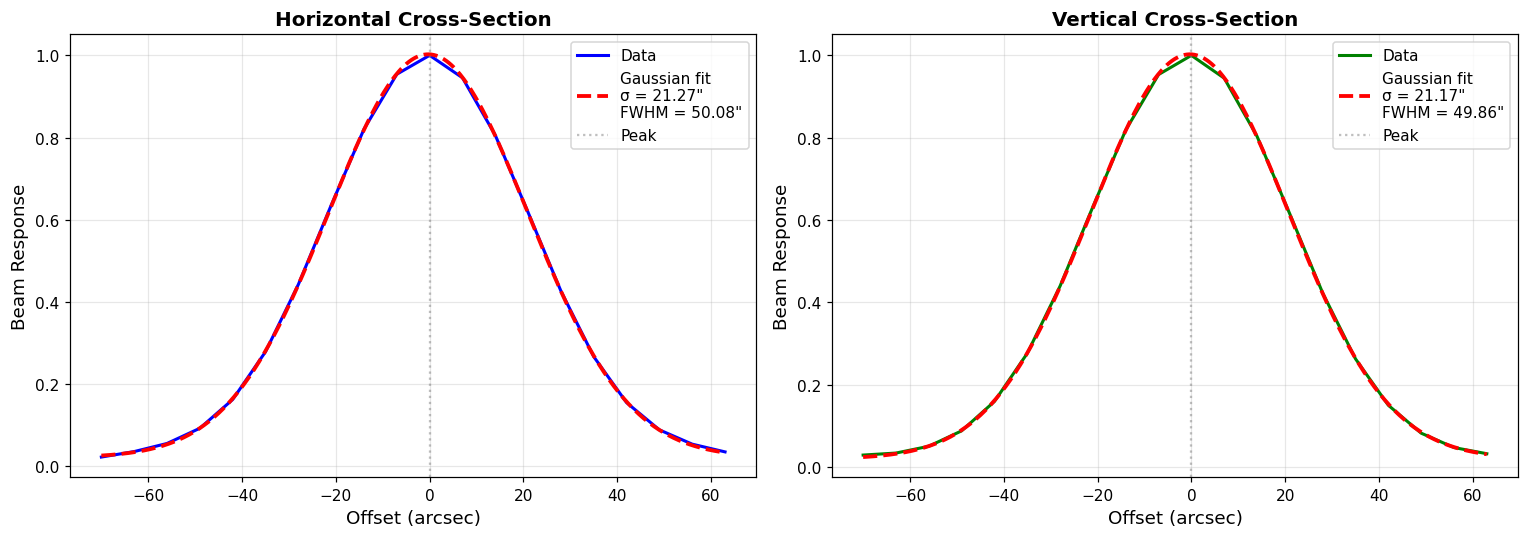


GAUSSIAN FIT RESULTS (Angular Units)

Horizontal:
  Sigma: 21.27 arcsec = 0.354 arcmin
  FWHM:  50.08 arcsec = 0.835 arcmin

Vertical:
  Sigma: 21.17 arcsec = 0.353 arcmin
  FWHM:  49.86 arcsec = 0.831 arcmin

Beam solid angle: 2829.34 arcsec² = 0.7859 arcmin²


In [ ]:
# Plot beam cross-sections with angular distance (arcsec)
from scipy.optimize import curve_fit

# Define Gaussian function
def gaussian(x, amp, mu, sigma, offset):
    """Gaussian function with offset"""
    return amp * np.exp(-0.5 * ((x - mu) / sigma)**2) + offset

# Get pixel scale from header

cdelt1 = np.abs(header['CDELT1']) * 3600  # deg to arcsec per pixel
cdelt2 = np.abs(header['CDELT2']) * 3600  # deg to arcsec per pixel
print(f"Pixel scale: {cdelt1:.4f} arcsec/px (x), {cdelt2:.4f} arcsec/px (y)")


fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=110)

# Find the actual peak location
peak_idx = np.unravel_index(np.argmax(plot_data), plot_data.shape)
cy, cx = peak_idx[0], peak_idx[1]
print(f"Peak location: pixel ({cx}, {cy})")
print(f"Peak value: {plot_data[cy, cx]:.4f}")

# === HORIZONTAL SLICE ===
ax1 = axes[0]
x_pixels = np.arange(plot_data.shape[1])
# Convert to angular offset from center (arcsec)
x_arcsec = (x_pixels - cx) * cdelt1
y_horizontal = plot_data[cy, :]

# Initial guesses in arcsec
amp_guess = y_horizontal.max() - y_horizontal.min()
offset_guess = y_horizontal.min()
half_max = (y_horizontal.max() + y_horizontal.min()) / 2
above_half = np.where(y_horizontal > half_max)[0]
if len(above_half) > 0:
    sigma_guess_arcsec = (above_half[-1] - above_half[0]) * cdelt1 / 2.355
else:
    sigma_guess_arcsec = 20 * cdelt1

# Fit Gaussian
try:
    p0_h = [amp_guess, 0, sigma_guess_arcsec, offset_guess]  # center at 0 arcsec
    bounds_h = ([0, -len(x_pixels)*cdelt1/2, 0.1, -np.inf], 
                [np.inf, len(x_pixels)*cdelt1/2, len(x_pixels)*cdelt1/2, np.inf])
    popt_h, pcov_h = curve_fit(gaussian, x_arcsec, y_horizontal, 
                                p0=p0_h, bounds=bounds_h, maxfev=10000)
    
    x_fit_arcsec = np.linspace(x_arcsec.min(), x_arcsec.max(), 500)
    y_fit_h = gaussian(x_fit_arcsec, *popt_h)
    
    fwhm_h_arcsec = 2.355 * np.abs(popt_h[2])
    
    ax1.plot(x_arcsec, y_horizontal, 'b-', linewidth=2, label='Data')
    ax1.plot(x_fit_arcsec, y_fit_h, 'r--', linewidth=2.5, 
             label=f'Gaussian fit\nσ = {np.abs(popt_h[2]):.2f}"\nFWHM = {fwhm_h_arcsec:.2f}"')
    fit_success_h = True
except Exception as e:
    ax1.plot(x_arcsec, y_horizontal, 'b-', linewidth=2, label='Data')
    print(f"Horizontal fit failed: {e}")
    fit_success_h = False

ax1.axvline(0, color='gray', linestyle=':', alpha=0.5, label='Peak')
ax1.set_xlabel('Offset (arcsec)', fontsize=12)
ax1.set_ylabel('Beam Response', fontsize=12)
ax1.set_title('Horizontal Cross-Section', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# === VERTICAL SLICE ===
ax2 = axes[1]
y_pixels = np.arange(plot_data.shape[0])
# Convert to angular offset from center (arcsec)
y_arcsec = (y_pixels - cy) * cdelt2
y_vertical = plot_data[:, cx]

# Initial guesses
amp_guess_v = y_vertical.max() - y_vertical.min()
offset_guess_v = y_vertical.min()
above_half_v = np.where(y_vertical > (y_vertical.max() + y_vertical.min()) / 2)[0]
if len(above_half_v) > 0:
    sigma_guess_v_arcsec = (above_half_v[-1] - above_half_v[0]) * cdelt2 / 2.355
else:
    sigma_guess_v_arcsec = 20 * cdelt2

# Fit Gaussian
try:
    p0_v = [amp_guess_v, 0, sigma_guess_v_arcsec, offset_guess_v]
    bounds_v = ([0, -len(y_pixels)*cdelt2/2, 0.1, -np.inf], 
                [np.inf, len(y_pixels)*cdelt2/2, len(y_pixels)*cdelt2/2, np.inf])
    popt_v, pcov_v = curve_fit(gaussian, y_arcsec, y_vertical, 
                                p0=p0_v, bounds=bounds_v, maxfev=10000)
    
    y_fit_arcsec = np.linspace(y_arcsec.min(), y_arcsec.max(), 500)
    y_fit_v = gaussian(y_fit_arcsec, *popt_v)
    
    fwhm_v_arcsec = 2.355 * np.abs(popt_v[2])
    
    ax2.plot(y_arcsec, y_vertical, 'g-', linewidth=2, label='Data')
    ax2.plot(y_fit_arcsec, y_fit_v, 'r--', linewidth=2.5, 
             label=f'Gaussian fit\nσ = {np.abs(popt_v[2]):.2f}"\nFWHM = {fwhm_v_arcsec:.2f}"')
    fit_success_v = True
except Exception as e:
    ax2.plot(y_arcsec, y_vertical, 'g-', linewidth=2, label='Data')
    print(f"Vertical fit failed: {e}")
    fit_success_v = False

ax2.axvline(0, color='gray', linestyle=':', alpha=0.5, label='Peak')
ax2.set_xlabel('Offset (arcsec)', fontsize=12)
ax2.set_ylabel('Beam Response', fontsize=12)
ax2.set_title('Vertical Cross-Section', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print fit results
print("\n" + "="*60)
print("GAUSSIAN FIT RESULTS (Angular Units)")
print("="*60)
if fit_success_h:
    print(f"\nHorizontal:")
    print(f"  Sigma: {np.abs(popt_h[2]):.2f} arcsec = {np.abs(popt_h[2])/60:.3f} arcmin")
    print(f"  FWHM:  {fwhm_h_arcsec:.2f} arcsec = {fwhm_h_arcsec/60:.3f} arcmin")

if fit_success_v:
    print(f"\nVertical:")
    print(f"  Sigma: {np.abs(popt_v[2]):.2f} arcsec = {np.abs(popt_v[2])/60:.3f} arcmin")
    print(f"  FWHM:  {fwhm_v_arcsec:.2f} arcsec = {fwhm_v_arcsec/60:.3f} arcmin")

# Calculate beam solid angle
if fit_success_h and fit_success_v:
    omega_beam = 1.133 * fwhm_h_arcsec * fwhm_v_arcsec  # arcsec^2
    print(f"\nBeam solid angle: {omega_beam:.2f} arcsec² = {omega_beam/3600:.4f} arcmin²")

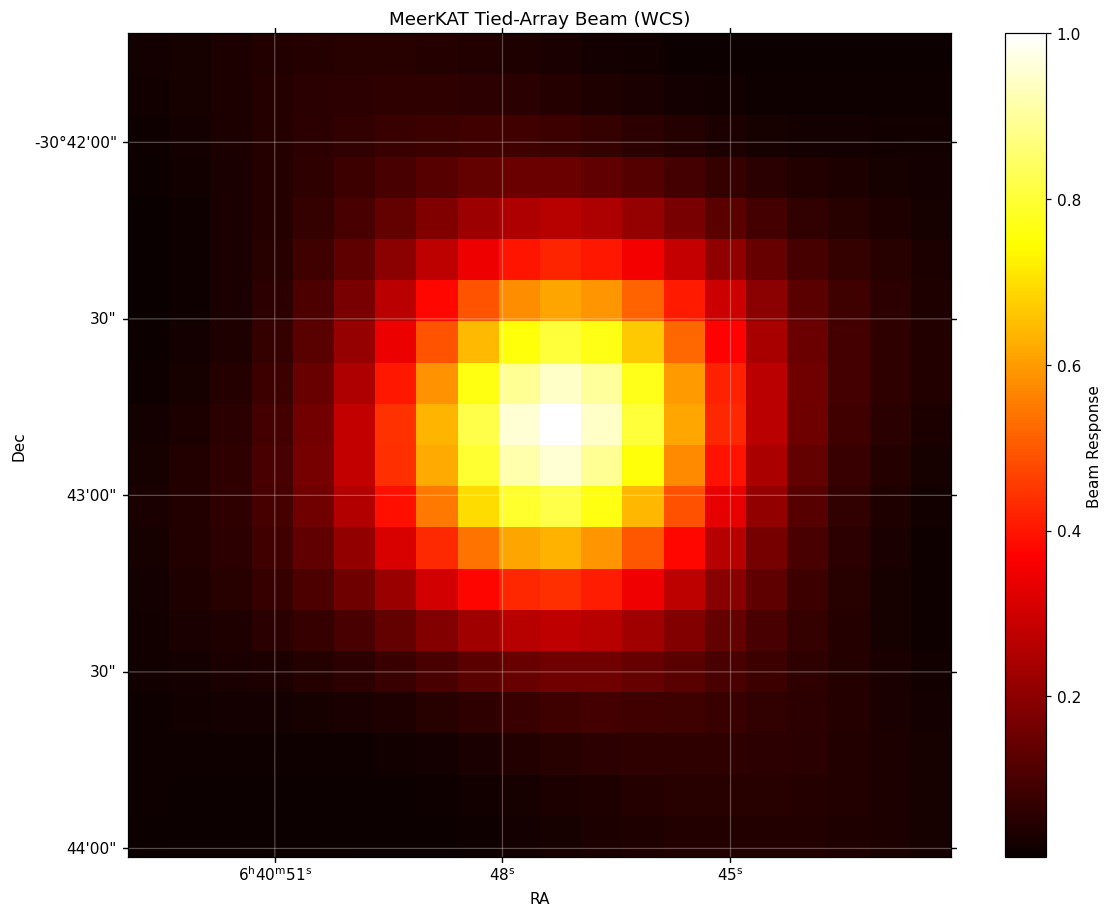

In [ ]:
# Plot with WCS coordinates (if available in header)
try:
    wcs = WCS(header, naxis=2)
    
    fig, ax = plt.subplots(figsize=(10, 8), dpi=110, 
                           subplot_kw={'projection': wcs})
    
    im = ax.imshow(plot_data, origin='lower', cmap='hot')
    plt.colorbar(im, ax=ax, label='Beam Response')
    ax.set_xlabel('RA')
    ax.set_ylabel('Dec')
    ax.set_title('MeerKAT Tied-Array Beam (WCS)')
    ax.grid(color='white', alpha=0.3)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"WCS projection not available: {e}")

Individual beam FWHM: 49.97 arcsec = 0.833 arcmin

Overlap at 25% response level:
  Radius at 25% response: 35.33 arcsec
  Beam separation: 70.67 arcsec = 1.178 arcmin
  This is 141.4% of FWHM

Beam positions (arcsec):
  Beam 1: (0.00, 40.80)
  Beam 2: (-35.33, -20.40)
  Beam 3: (35.33, -20.40)


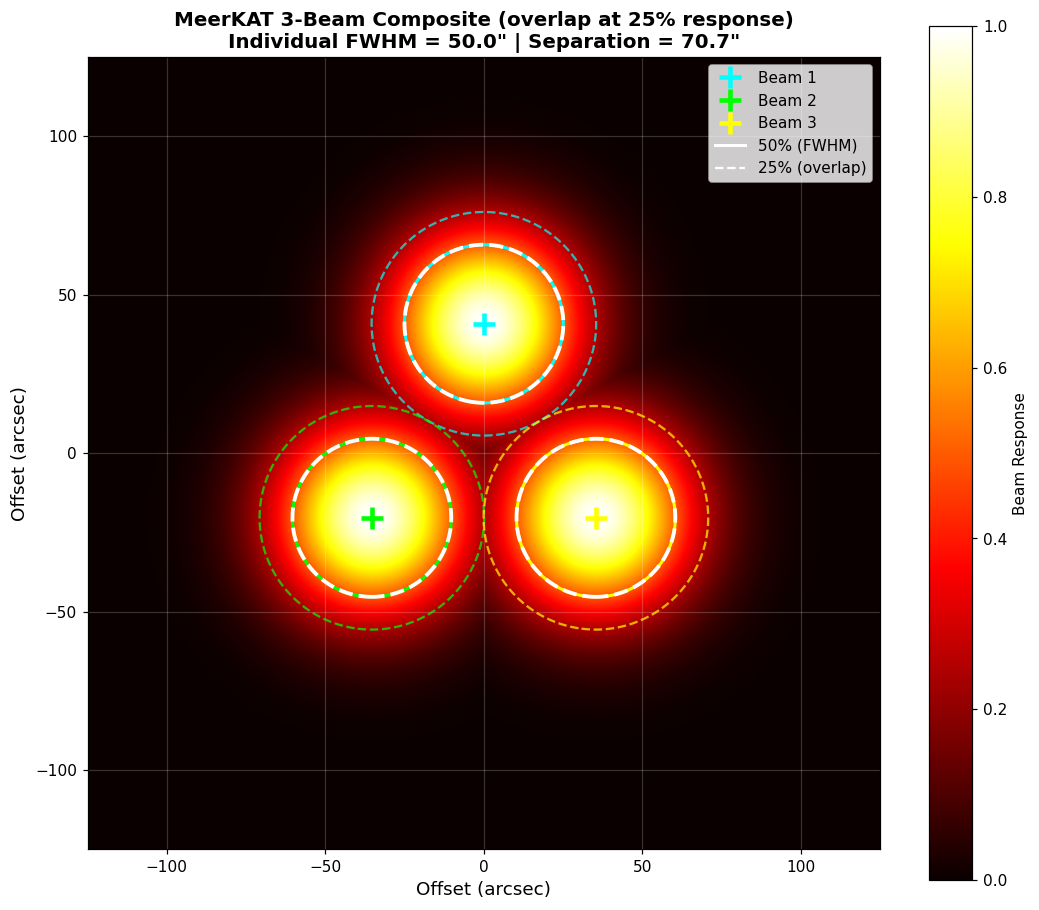


COMPOSITE BEAM SUMMARY (25% Response Overlap)
Individual beam FWHM: 49.97 arcsec = 0.833 arcmin
Overlap level: 25% response (beam response = 0.25 at overlap)
Radius at 25%: 35.33 arcsec
Beam separation: 70.67 arcsec = 1.178 arcmin
Triangle side length: 70.67 arcsec

Effective FoV (≥50% response):
  Area: 5857.0 arcsec² = 1.6269 arcmin²
  Equivalent diameter: 86.4 arcsec

Effective FoV (≥25% response):
  Area: 11720.5 arcsec² = 3.2557 arcmin²
  Equivalent diameter: 122.2 arcsec


In [ ]:
# Create composite beam from 3 tied-array beams with overlap at 25% response level

# Get the fitted Gaussian parameters (sigma in arcsec)
sigma_h = np.abs(popt_h[2])  # horizontal sigma in arcsec
sigma_v = np.abs(popt_v[2])  # vertical sigma in arcsec
sigma_avg = (sigma_h + sigma_v) / 2

# Calculate FWHM
fwhm_h = 2.355 * sigma_h
fwhm_v = 2.355 * sigma_v
fwhm_avg = (fwhm_h + fwhm_v) / 2

print(f"Individual beam FWHM: {fwhm_avg:.2f} arcsec = {fwhm_avg/60:.3f} arcmin")

# Define 2D Gaussian beam function
def gaussian_2d(x, y, x0, y0, sigma_x, sigma_y, amp=1.0):
    """2D Gaussian beam centered at (x0, y0)"""
    return amp * np.exp(-0.5 * (((x - x0) / sigma_x)**2 + ((y - y0) / sigma_y)**2))

# === OVERLAP AT 25% RESPONSE LEVEL ===
# For a Gaussian: response = exp(-0.5 * r²/σ²) = 0.25
# Solving for r: r = σ * sqrt(-2 * ln(0.25)) ≈ 1.665 * σ
overlap_response_level = 0.25
radius_at_overlap = sigma_avg * np.sqrt(-2 * np.log(overlap_response_level))

# Beam separation = 2 * radius at overlap level (so 25% contours just touch)
beam_separation = 2 * radius_at_overlap

print(f"\nOverlap at {overlap_response_level*100:.0f}% response level:")
print(f"  Radius at 25% response: {radius_at_overlap:.2f} arcsec")
print(f"  Beam separation: {beam_separation:.2f} arcsec = {beam_separation/60:.3f} arcmin")
print(f"  This is {beam_separation/fwhm_avg*100:.1f}% of FWHM")

# Create coordinate grid (in arcsec)
grid_size = fwhm_avg * 2.5  # enough to show full composite beam
n_pixels = 500
x = np.linspace(-grid_size, grid_size, n_pixels)
y = np.linspace(-grid_size, grid_size, n_pixels)
X, Y = np.meshgrid(x, y)

# Triangle beam arrangement (equilateral triangle centered at origin)
# Distance from center to each vertex
R = beam_separation / np.sqrt(3)  # for equilateral triangle with given side length

# Beam positions (one at top, two at bottom)
beam_positions = np.array([
    [0, R],                              # Top
    [-beam_separation/2, -R/2],          # Bottom-left
    [beam_separation/2, -R/2]            # Bottom-right
])

print(f"\nBeam positions (arcsec):")
for i, (bx, by) in enumerate(beam_positions):
    print(f"  Beam {i+1}: ({bx:.2f}, {by:.2f})")

# Create individual beams
beam1 = gaussian_2d(X, Y, beam_positions[0][0], beam_positions[0][1], sigma_h, sigma_v)
beam2 = gaussian_2d(X, Y, beam_positions[1][0], beam_positions[1][1], sigma_h, sigma_v)
beam3 = gaussian_2d(X, Y, beam_positions[2][0], beam_positions[2][1], sigma_h, sigma_v)

# Composite beam (maximum envelope)
composite = np.maximum(np.maximum(beam1, beam2), beam3)

# === SINGLE PLOT ===
fig, ax = plt.subplots(figsize=(10, 10), dpi=110)

# Plot composite beam
im = ax.imshow(composite, extent=[-grid_size, grid_size, -grid_size, grid_size],
               origin='lower', cmap='hot', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Beam Response', shrink=0.8)

# Draw contours for each individual beam
colors = ['cyan', 'lime', 'yellow']
labels = ['Beam 1', 'Beam 2', 'Beam 3']
for i, (beam, pos, color, label) in enumerate(zip([beam1, beam2, beam3], 
                                                   beam_positions, colors, labels)):
    # FWHM contour (50% of peak)
    ax.contour(X, Y, beam, levels=[0.5], colors=[color], linestyles='-', linewidths=2)
    # 25% contour (overlap boundary)
    ax.contour(X, Y, beam, levels=[0.25], colors=[color], linestyles='--', linewidths=1.5, alpha=0.7)
    # Mark beam center
    ax.plot(pos[0], pos[1], '+', color=color, markersize=15, markeredgewidth=3, label=label)

# Draw composite FWHM contour
ax.contour(X, Y, composite, levels=[0.5], colors='white', linestyles='--', linewidths=2.5)

# Add legend for contour levels
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='white', linestyle='-', linewidth=2, label='50% (FWHM)'),
    Line2D([0], [0], color='white', linestyle='--', linewidth=1.5, label='25% (overlap)')
]

# Add labels
ax.set_xlabel('Offset (arcsec)', fontsize=12)
ax.set_ylabel('Offset (arcsec)', fontsize=12)
ax.set_title(f'MeerKAT 3-Beam Composite (overlap at 25% response)\n'
             f'Individual FWHM = {fwhm_avg:.1f}" | Separation = {beam_separation:.1f}"', 
             fontsize=13, fontweight='bold')

handles, labels_leg = ax.get_legend_handles_labels()
handles.extend(legend_elements)
ax.legend(handles=handles, loc='upper right', fontsize=10)
ax.set_aspect('equal')
ax.grid(True, alpha=0.2, color='white')

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*60)
print("COMPOSITE BEAM SUMMARY (25% Response Overlap)")
print("="*60)
print(f"Individual beam FWHM: {fwhm_avg:.2f} arcsec = {fwhm_avg/60:.3f} arcmin")
print(f"Overlap level: 25% response (beam response = 0.25 at overlap)")
print(f"Radius at 25%: {radius_at_overlap:.2f} arcsec")
print(f"Beam separation: {beam_separation:.2f} arcsec = {beam_separation/60:.3f} arcmin")
print(f"Triangle side length: {beam_separation:.2f} arcsec")

# Calculate effective FoV
half_max_mask = composite >= 0.5
quarter_max_mask = composite >= 0.25
effective_area_50 = np.sum(half_max_mask) * (2 * grid_size / n_pixels)**2
effective_area_25 = np.sum(quarter_max_mask) * (2 * grid_size / n_pixels)**2
print(f"\nEffective FoV (≥50% response):")
print(f"  Area: {effective_area_50:.1f} arcsec² = {effective_area_50/3600:.4f} arcmin²")
print(f"  Equivalent diameter: {2*np.sqrt(effective_area_50/np.pi):.1f} arcsec")
print(f"\nEffective FoV (≥25% response):")
print(f"  Area: {effective_area_25:.1f} arcsec² = {effective_area_25/3600:.4f} arcmin²")
print(f"  Equivalent diameter: {2*np.sqrt(effective_area_25/np.pi):.1f} arcsec")

Using beam parameters at 856 MHz
  Sigma_x: 26.88 arcsec
  Sigma_y: 26.73 arcsec
  FWHM_avg: 63.12 arcsec
  Beam separation (from CSV): 62.84 arcsec

Beam positions (arcsec):
  Beam 1: (0.00, 36.28)
  Beam 2: (-31.42, -18.14)
  Beam 3: (31.42, -18.14)

RANDOM FRB GENERATED at 856 MHz

FRB Position: (1.500, 19.566) arcsec
Nearest Beam: Beam 1
Angular Offset: 16.7807 arcsec
Beam Response: 0.8212 (82.1%)


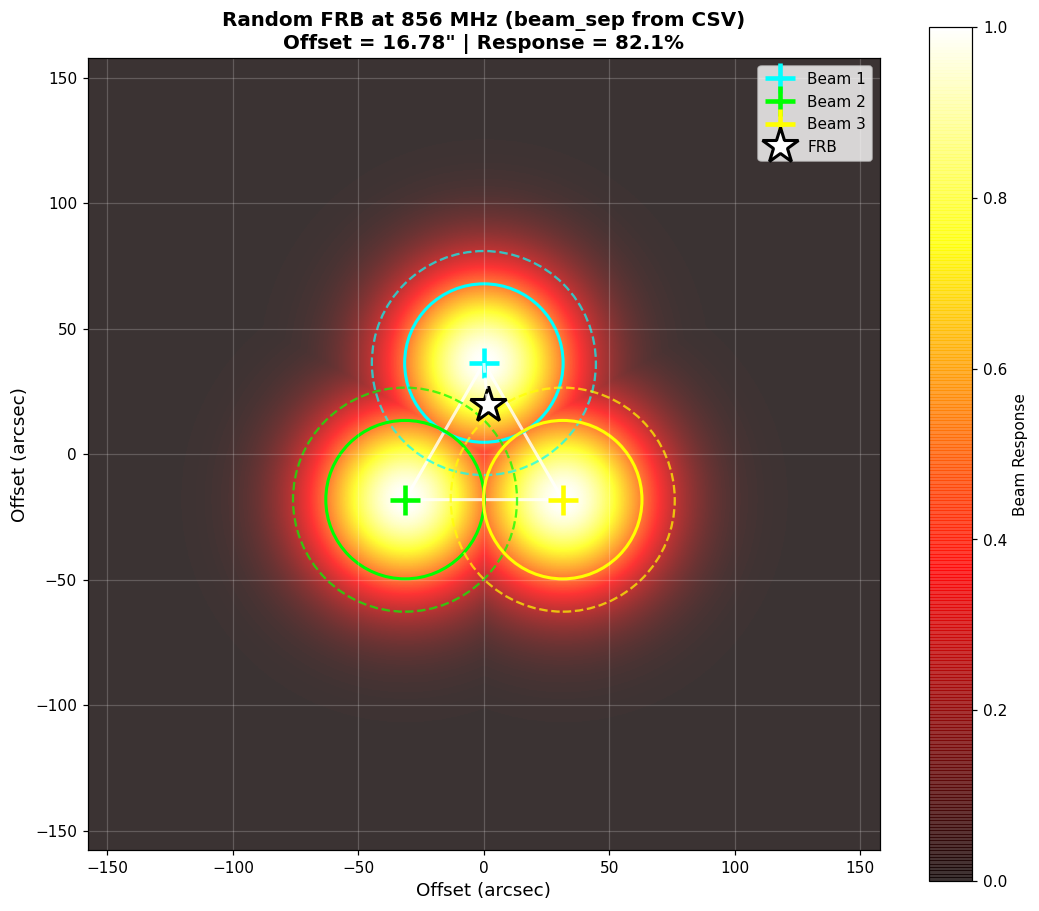

In [ ]:
# Generate a single random FRB within the central triangular region
# Using beam parameters from CSV at 856 MHz

import pandas as pd

# Load beam parameters from CSV
beam_params = pd.read_csv('/Users/xuziying/Downloads/MeerKAT_beam_n_comp/beam_parameters.csv')

# Get parameters at 856 MHz
target_freq = 856.0
params_856 = beam_params[beam_params['freq_MHz'] == target_freq].iloc[0]

sigma_h = params_856['sigma_x']  # horizontal sigma in arcsec
sigma_v = params_856['sigma_y']  # vertical sigma in arcsec
sigma_avg = params_856['sigma_avg']
fwhm_avg = params_856['fwhm_avg']
beam_separation = params_856['beam_sep']  # from CSV (62.84 arcsec)

print(f"Using beam parameters at {target_freq:.0f} MHz")
print(f"  Sigma_x: {sigma_h:.2f} arcsec")
print(f"  Sigma_y: {sigma_v:.2f} arcsec")
print(f"  FWHM_avg: {fwhm_avg:.2f} arcsec")
print(f"  Beam separation (from CSV): {beam_separation:.2f} arcsec")

# Define 2D Gaussian beam function
def gaussian_2d(x, y, x0, y0, sigma_x, sigma_y, amp=1.0):
    """2D Gaussian beam centered at (x0, y0)"""
    return amp * np.exp(-0.5 * (((x - x0) / sigma_x)**2 + ((y - y0) / sigma_y)**2))

# Triangle beam arrangement (equilateral triangle centered at origin)
R = beam_separation / np.sqrt(3)

# Beam positions (one at top, two at bottom)
beam_positions = np.array([
    [0, R],                              # Top
    [-beam_separation/2, -R/2],          # Bottom-left
    [beam_separation/2, -R/2]            # Bottom-right
])

print(f"\nBeam positions (arcsec):")
for i, (bx, by) in enumerate(beam_positions):
    print(f"  Beam {i+1}: ({bx:.2f}, {by:.2f})")

# Create coordinate grid for plotting
grid_size = fwhm_avg * 2.5
n_pixels = 500
x = np.linspace(-grid_size, grid_size, n_pixels)
y = np.linspace(-grid_size, grid_size, n_pixels)
X, Y = np.meshgrid(x, y)

# Create individual beams and composite
beam1 = gaussian_2d(X, Y, beam_positions[0][0], beam_positions[0][1], sigma_h, sigma_v)
beam2 = gaussian_2d(X, Y, beam_positions[1][0], beam_positions[1][1], sigma_h, sigma_v)
beam3 = gaussian_2d(X, Y, beam_positions[2][0], beam_positions[2][1], sigma_h, sigma_v)
composite = np.maximum(np.maximum(beam1, beam2), beam3)

def sample_single_frb_triangle(beam_positions, sigma_x, sigma_y):
    """
    Sample a single random FRB position ONLY within the triangular region 
    formed by connecting the 3 beam centers.
    """
    all_beam_x = beam_positions[:, 0]
    all_beam_y = beam_positions[:, 1]
    x_min, x_max = all_beam_x.min(), all_beam_x.max()
    y_min, y_max = all_beam_y.min(), all_beam_y.max()
    
    def point_in_triangle(p, v0, v1, v2):
        def sign(p1, p2, p3):
            return (p1[0] - p3[0]) * (p2[1] - p3[1]) - (p2[0] - p3[0]) * (p1[1] - p3[1])
        d1 = sign(p, v0, v1)
        d2 = sign(p, v1, v2)
        d3 = sign(p, v2, v0)
        has_neg = (d1 < 0) or (d2 < 0) or (d3 < 0)
        has_pos = (d1 > 0) or (d2 > 0) or (d3 > 0)
        return not (has_neg and has_pos)
    
    while True:
        x = np.random.uniform(x_min, x_max)
        y = np.random.uniform(y_min, y_max)
        
        if not point_in_triangle([x, y], beam_positions[0], beam_positions[1], beam_positions[2]):
            continue
        
        distances = np.array([np.sqrt((x - bx)**2 + (y - by)**2) for bx, by in beam_positions])
        nearest_idx = np.argmin(distances)
        offset = distances[nearest_idx]
        
        bx, by = beam_positions[nearest_idx]
        response = np.exp(-0.5 * (((x - bx)/sigma_x)**2 + ((y - by)/sigma_y)**2))
        
        return np.array([x, y]), nearest_idx, offset, response

# Generate a single random FRB
frb_pos, nearest_beam, angular_offset, response = sample_single_frb_triangle(
    beam_positions, sigma_h, sigma_v
)

# Calculate max offset for reference (25% response at 856 MHz)
max_offset_25 = sigma_avg * np.sqrt(-2 * np.log(0.25))

# Print results
print("\n" + "="*60)
print(f"RANDOM FRB GENERATED at {target_freq:.0f} MHz")
print("="*60)
print(f"\nFRB Position: ({frb_pos[0]:.3f}, {frb_pos[1]:.3f}) arcsec")
print(f"Nearest Beam: Beam {nearest_beam + 1}")
print(f"Angular Offset: {angular_offset:.4f} arcsec")
print(f"Beam Response: {response:.4f} ({response*100:.1f}%)")

# === VISUALIZATION ===
fig, ax = plt.subplots(figsize=(10, 10), dpi=110)

im = ax.imshow(composite, extent=[-grid_size, grid_size, -grid_size, grid_size],
               origin='lower', cmap='hot', vmin=0, vmax=1, alpha=0.8)
plt.colorbar(im, ax=ax, label='Beam Response', shrink=0.8)

# Draw the central triangle
triangle = plt.Polygon(beam_positions, fill=False, edgecolor='white', 
                       linewidth=2, linestyle='-', alpha=0.8)
ax.add_patch(triangle)

# Draw beam contours
colors = ['cyan', 'lime', 'yellow']
for i, (pos, color) in enumerate(zip(beam_positions, colors)):
    circle_50 = plt.Circle(pos, fwhm_avg/2, fill=False, color=color, linewidth=2)
    ax.add_patch(circle_50)
    circle_25 = plt.Circle(pos, max_offset_25, fill=False, color=color, linewidth=1.5, linestyle='--', alpha=0.7)
    ax.add_patch(circle_25)
    ax.plot(pos[0], pos[1], '+', color=color, markersize=20, markeredgewidth=3, label=f'Beam {i+1}')

# Plot FRB
ax.plot(frb_pos[0], frb_pos[1], '*', color='white', markersize=25, 
        markeredgecolor='black', markeredgewidth=2, label='FRB')
ax.plot([frb_pos[0], beam_positions[nearest_beam][0]], 
        [frb_pos[1], beam_positions[nearest_beam][1]], 'w--', linewidth=2, alpha=0.8)

ax.set_xlabel('Offset (arcsec)', fontsize=12)
ax.set_ylabel('Offset (arcsec)', fontsize=12)
ax.set_title(f'Random FRB at {target_freq:.0f} MHz (beam_sep from CSV)\n'
             f'Offset = {angular_offset:.2f}" | Response = {response*100:.1f}%', 
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.set_aspect('equal')
ax.set_xlim(-grid_size, grid_size)
ax.set_ylim(-grid_size, grid_size)
ax.grid(True, alpha=0.2, color='white')

plt.tight_layout()
plt.show()

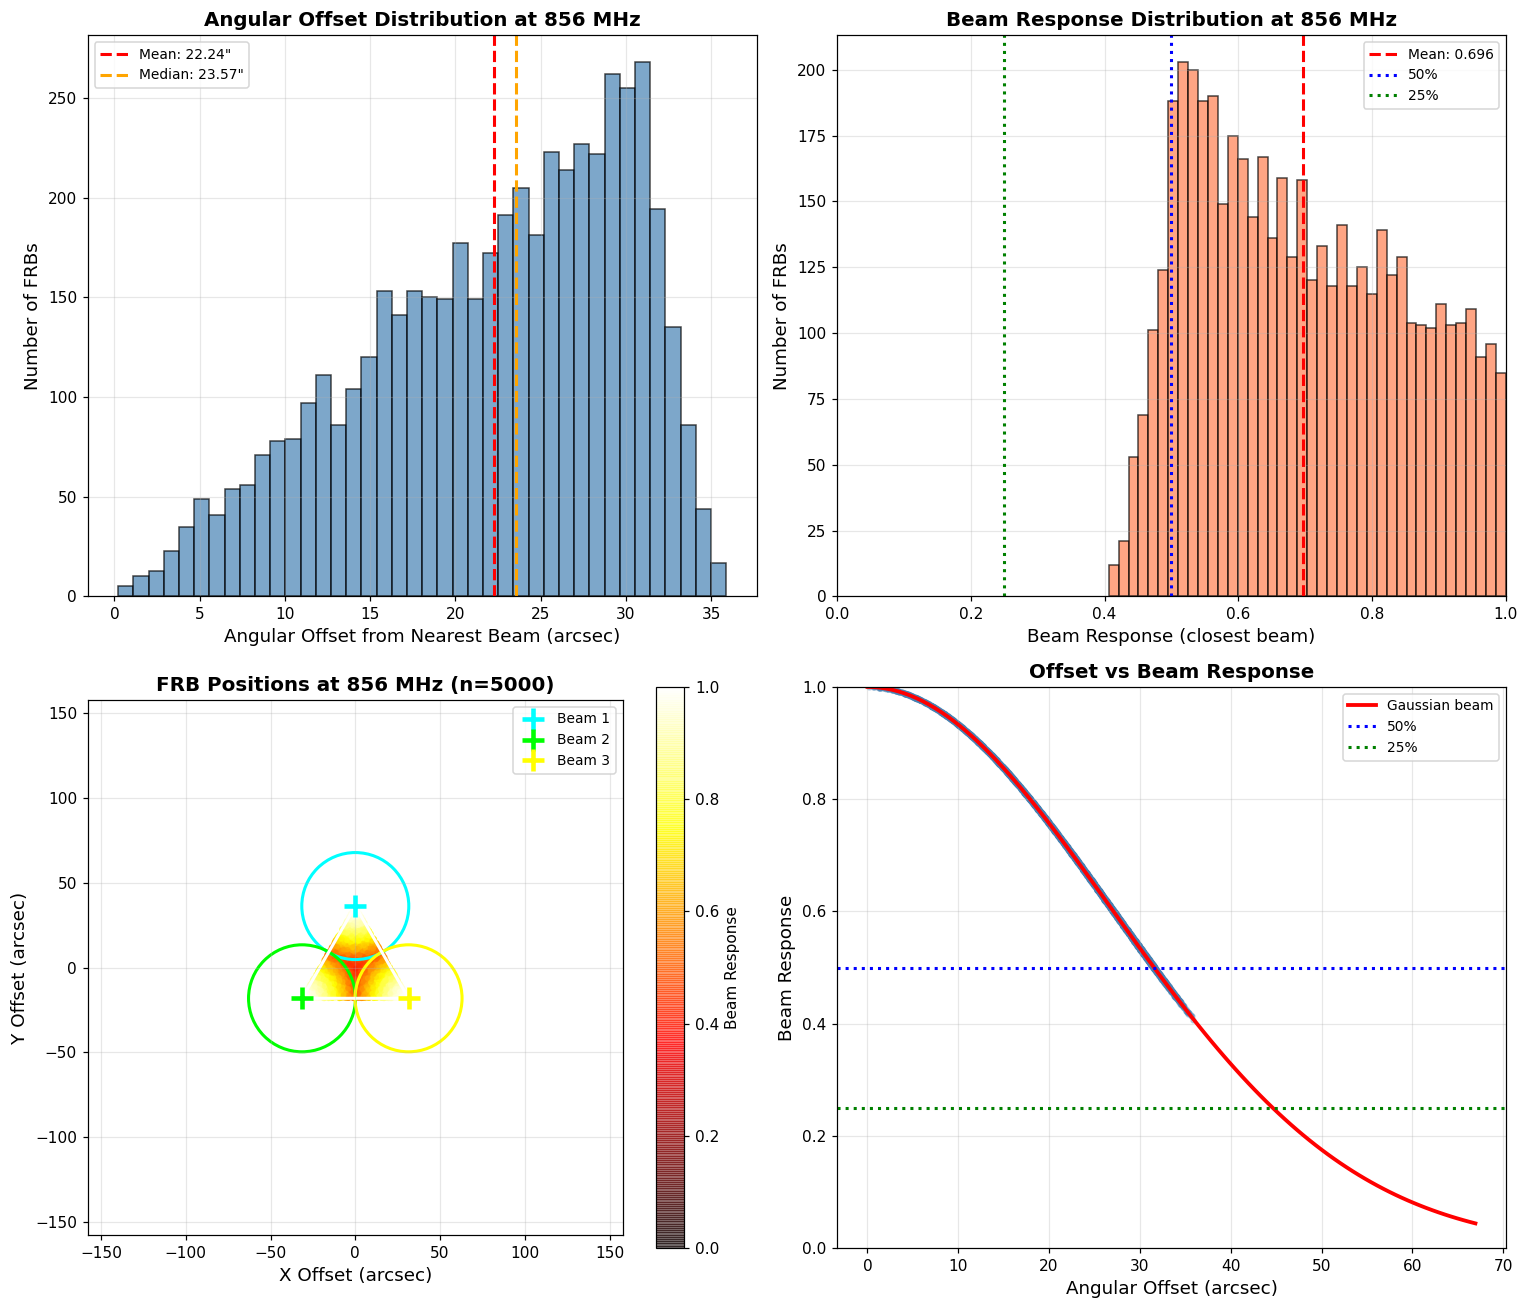


STATISTICS at 856 MHz (n=5000 FRBs)
Beam separation from CSV: 62.84 arcsec

Angular Offset: Mean=22.241, Median=23.573 arcsec
Beam Response: Mean=0.6964 (69.6%)

FRBs per beam:
  Beam 1: 1628 (32.6%)
  Beam 2: 1693 (33.9%)
  Beam 3: 1679 (33.6%)


In [ ]:
# Generate multiple FRBs within the central triangular region
# Using beam parameters from CSV at 856 MHz

def sample_frb_in_triangle(beam_positions, sigma_x, sigma_y, n_samples=1):
    """
    Sample random FRB positions ONLY within the triangular region 
    formed by connecting the 3 beam centers.
    """
    frb_positions = []
    nearest_beam_idx = []
    angular_offsets = []
    beam_responses = []
    
    all_beam_x = beam_positions[:, 0]
    all_beam_y = beam_positions[:, 1]
    x_min, x_max = all_beam_x.min(), all_beam_x.max()
    y_min, y_max = all_beam_y.min(), all_beam_y.max()
    
    def point_in_triangle(p, v0, v1, v2):
        def sign(p1, p2, p3):
            return (p1[0] - p3[0]) * (p2[1] - p3[1]) - (p2[0] - p3[0]) * (p1[1] - p3[1])
        d1 = sign(p, v0, v1)
        d2 = sign(p, v1, v2)
        d3 = sign(p, v2, v0)
        has_neg = (d1 < 0) or (d2 < 0) or (d3 < 0)
        has_pos = (d1 > 0) or (d2 > 0) or (d3 > 0)
        return not (has_neg and has_pos)
    
    while len(frb_positions) < n_samples:
        x = np.random.uniform(x_min, x_max)
        y = np.random.uniform(y_min, y_max)
        
        if not point_in_triangle([x, y], beam_positions[0], beam_positions[1], beam_positions[2]):
            continue
        
        distances = np.array([np.sqrt((x - bx)**2 + (y - by)**2) for bx, by in beam_positions])
        nearest_idx = np.argmin(distances)
        offset = distances[nearest_idx]
        
        bx, by = beam_positions[nearest_idx]
        response = np.exp(-0.5 * (((x - bx)/sigma_x)**2 + ((y - by)/sigma_y)**2))
        
        frb_positions.append([x, y])
        nearest_beam_idx.append(nearest_idx)
        angular_offsets.append(offset)
        beam_responses.append(response)
    
    return (np.array(frb_positions), np.array(nearest_beam_idx), 
            np.array(angular_offsets), np.array(beam_responses))

# === Generate FRBs within the triangle ===
n_frbs = 5000

frb_positions_arr, nearest_beams, angular_offsets, beam_responses = sample_frb_in_triangle(
    beam_positions, sigma_h, sigma_v, n_samples=n_frbs
)

max_offset_25 = sigma_avg * np.sqrt(-2 * np.log(0.25))

# === PLOTTING ===
fig, axes = plt.subplots(2, 2, figsize=(14, 12), dpi=110)

# Plot 1: Angular offset distribution
ax1 = axes[0, 0]
ax1.hist(angular_offsets, bins=40, alpha=0.7, color='steelblue', edgecolor='black')
ax1.axvline(np.mean(angular_offsets), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {np.mean(angular_offsets):.2f}"')
ax1.axvline(np.median(angular_offsets), color='orange', linestyle='--', linewidth=2,
            label=f'Median: {np.median(angular_offsets):.2f}"')
ax1.set_xlabel('Angular Offset from Nearest Beam (arcsec)', fontsize=12)
ax1.set_ylabel('Number of FRBs', fontsize=12)
ax1.set_title(f'Angular Offset Distribution at {target_freq:.0f} MHz', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Beam response distribution
ax2 = axes[0, 1]
ax2.hist(beam_responses, bins=40, alpha=0.7, color='coral', edgecolor='black')
ax2.axvline(np.mean(beam_responses), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {np.mean(beam_responses):.3f}')
ax2.axvline(0.5, color='blue', linestyle=':', linewidth=2, label='50%')
ax2.axvline(0.25, color='green', linestyle=':', linewidth=2, label='25%')
ax2.set_xlabel('Beam Response (closest beam)', fontsize=12)
ax2.set_ylabel('Number of FRBs', fontsize=12)
ax2.set_title(f'Beam Response Distribution at {target_freq:.0f} MHz', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 1)

# Plot 3: FRB positions scatter plot
ax3 = axes[1, 0]
scatter = ax3.scatter(frb_positions_arr[:, 0], frb_positions_arr[:, 1], 
                      c=beam_responses, cmap='hot', s=8, alpha=0.6, vmin=0, vmax=1)
plt.colorbar(scatter, ax=ax3, label='Beam Response')

colors = ['cyan', 'lime', 'yellow']
for i, (pos, color) in enumerate(zip(beam_positions, colors)):
    circle_50 = plt.Circle(pos, fwhm_avg/2, fill=False, color=color, linewidth=2)
    ax3.add_patch(circle_50)
    ax3.plot(pos[0], pos[1], '+', color=color, markersize=15, markeredgewidth=3, label=f'Beam {i+1}')

triangle = plt.Polygon(beam_positions, fill=False, edgecolor='white', linewidth=2)
ax3.add_patch(triangle)

ax3.set_xlabel('X Offset (arcsec)', fontsize=12)
ax3.set_ylabel('Y Offset (arcsec)', fontsize=12)
ax3.set_title(f'FRB Positions at {target_freq:.0f} MHz (n={n_frbs})', fontsize=13, fontweight='bold')
ax3.set_aspect('equal')
ax3.set_xlim(-grid_size, grid_size)
ax3.set_ylim(-grid_size, grid_size)
ax3.legend(loc='upper right', fontsize=9)
ax3.grid(True, alpha=0.3)

# Plot 4: Offset vs response
ax4 = axes[1, 1]
ax4.scatter(angular_offsets, beam_responses, alpha=0.3, s=10, c='steelblue')
theta_theory = np.linspace(0, max_offset_25 * 1.5, 100)
response_theory = np.exp(-0.5 * (theta_theory / sigma_avg)**2)
ax4.plot(theta_theory, response_theory, 'r-', linewidth=2.5, label='Gaussian beam')
ax4.axhline(0.5, color='blue', linestyle=':', linewidth=2, label='50%')
ax4.axhline(0.25, color='green', linestyle=':', linewidth=2, label='25%')
ax4.set_xlabel('Angular Offset (arcsec)', fontsize=12)
ax4.set_ylabel('Beam Response', fontsize=12)
ax4.set_title('Offset vs Beam Response', fontsize=13, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)
ax4.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# === STATISTICS ===
print("\n" + "="*70)
print(f"STATISTICS at {target_freq:.0f} MHz (n={n_frbs} FRBs)")
print(f"Beam separation from CSV: {beam_separation:.2f} arcsec")
print("="*70)
print(f"\nAngular Offset: Mean={np.mean(angular_offsets):.3f}, Median={np.median(angular_offsets):.3f} arcsec")
print(f"Beam Response: Mean={np.mean(beam_responses):.4f} ({np.mean(beam_responses)*100:.1f}%)")
print(f"\nFRBs per beam:")
for i in range(3):
    count = np.sum(nearest_beams == i)
    print(f"  Beam {i+1}: {count} ({count/n_frbs:.1%})")

In [ ]:
dnu = 856/16
nu_chan = []
for i in range (17):
    nu_chan.append(856 + i*dnu)
print(nu_chan)

[856.0, 909.5, 963.0, 1016.5, 1070.0, 1123.5, 1177.0, 1230.5, 1284.0, 1337.5, 1391.0, 1444.5, 1498.0, 1551.5, 1605.0, 1658.5, 1712.0]
